# Notebook 3: MAPPO Training — Configurations A, B, C, D

Trains the four-agent cooperative microgrid (Building A, Building B, Battery, Grid)
using MAPPO (Multi-Agent Proximal Policy Optimization): decentralized actors,
one centralized critic that sees the full global state during training only.

Each of the four reward-weighting configurations from Section 3.3 of the report
is trained independently, across multiple random seeds, so their training curves
and final policies can be compared in Notebook 4 (Evaluation).

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import sys
!{sys.executable} -m pip install torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from pathlib import Path
import copy
import json

In [3]:
from microgrid_env import MicrogridEnv, AGENTS, get_electricity_price, get_carbon_intensity, calibrate_reward_norms, df
from pathlib import Path
import pandas as pd

PROJ_DIR = Path(r"C:\Users\prish\building-data-genome-project-2")
PROCESSED_DIR = PROJ_DIR / "data" / "processed"
DATA_FILE = PROCESSED_DIR / "bdg2_clean.csv"

print(df[["building_a","building_b","solar"]].describe())   # sanity check: max should be 1.0 for all three
stats = calibrate_reward_norms(lambda: MicrogridEnv(data=df, episode_length=24))
COST_NORM = stats["raw_cost"]["p90"]
EMISSIONS_NORM = stats["raw_emissions"]["p90"]
print(COST_NORM)
print(EMISSIONS_NORM)

                     building_a  building_b  solar
timestamp                                         
2016-01-01 00:00:00     56.6201     65.2500   0.02
2016-01-01 01:00:00     59.8800     61.5000   0.01
2016-01-01 02:00:00     63.5001     63.7500   0.02
2016-01-01 03:00:00     59.7501     65.5001   0.02
2016-01-01 04:00:00     56.2501     67.5001   0.00

Shape: (8575, 3)

Columns: ['building_a', 'building_b', 'solar']
        building_a   building_b        solar
count  8575.000000  8575.000000  8575.000000
mean      0.508046     0.565472     0.213844
std       0.100270     0.088379     0.323527
min       0.220238     0.095745     0.000000
25%       0.435952     0.500000     0.000620
50%       0.501428     0.569149     0.001859
75%       0.574404     0.630320     0.373606
max       1.000000     1.000000     1.000000
        building_a   building_b        solar
count  8575.000000  8575.000000  8575.000000
mean      0.508046     0.565472     0.213844
std       0.100270     0.088379     0

In [4]:
print(AGENTS)
print(df.shape)
env = MicrogridEnv(data=df, episode_length=24)
print(env.reset(seed=0)[0]["building_a"].shape)

['building_a', 'building_b', 'battery', 'grid']
(8575, 3)
(11,)


set_seed(seed) — seeds NumPy and PyTorch's RNGs together so a full training run (env randomness + network initialization + action sampling) is reproducible given a seed. 
Report Section 3.2 requires "multiple independent runs using different random seeds," so this is called once per run.

In [5]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Actor Network - per agent.

Each of the 4 agents gets their own Actor instance (separate weights) since they have different roles.
BUT - all share the same architecture (keeps configs fair).

nn.Sequential — stacks layers in order: 
- Two 64-unit fully-connected + ReLU layers  
- Then a final linear layer producing 3 action logits.

nn.Linear(in, out) — a fully connected layer.

nn.ReLU() — the activation function between layers.

Categorical(logits=...) — converts raw logits into a sampleable discrete distribution; 
- .sample() picks an action, 
- .log_prob(action) gives the log-probability PPO needs.

In [6]:
class Actor(nn.Module):
    """
    Decentralized policy network. Maps an agent's LOCAL observation (11-dim)
    to a probability distribution over its 3 discrete actions.
    """
    def __init__(self, obs_dim=11, action_dim=3,hidden_dim=64):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
    def forward(self, obs):
        logits=self.net(obs)
        return Categorical(logits=logits)

# Critic Network (Shared, Centralized)

Same 64-64-ReLU shape as the actor, but a single shared instance across all 4 agents — this is the "shared critic has access to the full system state" design from Section 3.2, and the centralized-training half of CTDE.

In [7]:
class Critic(nn.Module):
    """
    Centralized value network. Maps the GLOBAL state (13-dim) to a single
    scalar state-value estimate. Used only during training (CTDE).
    """
    def __init__(self, state_dim=13, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, global_state):
        return self.net(global_state).squeeze(-1)

Rollout buffer:

Collects one full 24-step episode's observations, actions, log-probabilities, the (shared, cooperative) reward, termination flags, and global states — everything needed to compute advantages and run a PPO update afterward. 

reset() clears it for the next episode/rollout batch.

In [8]:
class RolloutBuffer:
    """
    Stores one episode's worth of transitions for every agent, plus the
    shared global states, for a single PPO update.
    """
    def __init__(self, agents):
        self.agents = agents
        self.reset()

    def reset(self):
        self.obs = {a: [] for a in self.agents}
        self.actions = {a: [] for a in self.agents}
        self.log_probs = {a: [] for a in self.agents}
        self.rewards = []
        self.dones = []
        self.global_states = []

    def add(self, obs, actions, log_probs, reward, done, global_state):
        for a in self.agents:
            self.obs[a].append(obs[a])
            self.actions[a].append(actions[a])
            self.log_probs[a].append(log_probs[a])
        self.rewards.append(reward)
        self.dones.append(done)
        self.global_states.append(global_state)

Generalized Advantage Estimation (GAE)

- gamma — discount factor for future rewards.
- lam (λ) — GAE's bias/variance trade-off parameter.
- The reversed loop computes the standard GAE recursion: temporal-difference error (delta) at each step, accumulated backward through the episode into last_gae.
- Returns both advantages (used in the PPO policy loss) and returns (the target for the critic's value loss).

In [9]:
def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    """
    Computes advantages and discounted returns using GAE.
    rewards, values, dones: 1D lists/arrays of length T (values has length T+1,
    including the bootstrap value after the last step).
    """
    T = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    last_gae = 0.0

    for t in reversed(range(T)):
        mask = 1.0 - dones[t]
        delta = rewards[t] + gamma * values[t + 1] * mask - values[t]
        last_gae = delta + gamma * lam * mask * last_gae
        advantages[t] = last_gae

    returns = advantages + np.array(values[:T], dtype=np.float32)
    return advantages, returns

In [10]:
#Weight functions for Configurations A and B (fixed and tuned)
#Both are constants - ignore grid state

def weights_config_A(env, prev_weights):
    """Configuration A — Fixed Equal Weights."""
    return np.array([1/3, 1/3, 1/3], dtype=np.float32)

def weights_config_B(env, prev_weights):
    """Configuration B — Fixed Tuned Weights (cost-dominant)."""
    return np.array([0.5, 0.3, 0.2], dtype=np.float32)

# Grid state signals: L(t), G(t), P(t)

- L(t): Grid Load (as a fraction of peak capacity)
- G(t): Renewable Availability (fraction of current demand met by solar)
- P(t): Carbon/price signal (reuses get_carbon_intensity)

These three signals are what both Configuration C (discrete thresholds) and Configuration D (continuous sigmoid) use to decide which objective to prioritize.

In [11]:
def get_grid_state_signals(env):
    """
    Computes the three observable grid-state variables that drive adaptive
    weighting (Report Section 2.2):
      L(t) - grid load, as a fraction of peak capacity
      G(t) - renewable availability, fraction of current demand met by solar
      P(t) - carbon/price signal (reuses get_carbon_intensity)
    """
    row = env.data.iloc[env.current_step]
    hour = pd.Timestamp(row["timestamp"]).hour

    total_demand = row["building_a"] + row["building_b"]
    L = min(env.grid_import, 1.0)                      # normalized grid load
    G = min(row["solar"] / max(total_demand, 1e-6), 1.0)  # renewable coverage fraction
    P = get_carbon_intensity(row["solar"])              # carbon/price signal

    return L, G, P

Configuration C Weighing Mechanism:

- Predefined discrete threshold conditions.
High grid load (>0.7) takes priority → Emergency; 
else high renewable availability or high carbon price → Sustainability; 
otherwise → Economy.
- No smoothing — the return value jumps directly to a target vector, which is the discrete-switching behavior Configuration D is designed to improve on.

(TARGET_WEIGHTS — the three named profiles from Section 3.3 (Economy / Sustainability / Emergency), matching the mode targets used for Config D so the two are directly comparable.)

In [12]:
#Weight function for Configuration C (Discrete Adaptive)

TARGET_WEIGHTS = {
    "economy":        np.array([0.6, 0.2, 0.2], dtype=np.float32),
    "sustainability":np.array([0.2, 0.6, 0.2], dtype=np.float32),
    "emergency":      np.array([0.2, 0.2, 0.6], dtype=np.float32),
}

def weights_config_C(env, prev_weights):
    """
    Configuration C — Discrete Adaptive Weights.
    Switches instantly between Economy / Sustainability / Emergency profiles
    based on threshold conditions on L(t), G(t), P(t).
    """
    L, G, P = get_grid_state_signals(env)

    if L > 0.7:
        return TARGET_WEIGHTS["emergency"]
    elif G > 0.5 or P > 0.6:
        return TARGET_WEIGHTS["sustainability"]
    else:
        return TARGET_WEIGHTS["economy"]

Configuration D Weighting Mechanism (AMORM Continuous):

- Continuous adaptive weights.
- Uses sigmoid function.

Binary classification/regular discrete switching: 
- Jumps straight to target
- Causes instant full sized weight change
- For a tinyy change in threshold boundary crossing (e.g. L(t) going from 0.699 to 0.701), agent gets a wildly different reward for essentially the same situation.
- Fixed small step size (weights adapt just as slowly during an emergency like a huge grid load spike, as during a calm normal drift) - not responsive enough when it actually matters

SIGMOID FUNCTION: Outputs  a value between 0 to 1 that scales the step size based on HOW MUCH GRID LOAD ACTUALLY CHANGED SINCE LAST STEP.
- Small ΔL(t) (conditions barely changing) → sigmoid output near 0 → tiny step → weights barely move. (smooth, gradual transitions during normal operation.)
- Large ΔL(t) (conditions swinging sharply) → sigmoid output near 1 → step size approaches its max (alpha) → weights move quickly toward the new target. This is what lets the system still respond promptly to a real emergency instead of always crawling.

- Sigmoid's S-shape means this scaling isn't linear — it saturates smoothly at both ends (never overshoots into extreme step sizes, never fully stalls), which is exactly the "gradual, not abrupt" property.


In [13]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def get_target_weights(env):
    """Same target-selection rule as Config C, used as the moving target for D."""
    L, G, P = get_grid_state_signals(env)
    if L > 0.7:
        return TARGET_WEIGHTS["emergency"]
    elif G > 0.5 or P > 0.6:
        return TARGET_WEIGHTS["sustainability"]
    else:
        return TARGET_WEIGHTS["economy"]

def weights_config_D(env, prev_weights, alpha=0.3, prev_L_smooth=[None]):
    """
    Configuration D — AMORM Continuous Adaptive Weights (with smoothed L(t)
    to reduce step-to-step jitter that was inflating RSV).
    """
    L, G, P = get_grid_state_signals(env)
    target = get_target_weights(env)

    if prev_L_smooth[0] is None:
        L_smooth = L
        delta_L = 0.0
    else:
        L_smooth = 0.8 * prev_L_smooth[0] + 0.2 * L   # exponential smoothing
        delta_L = abs(L_smooth - prev_L_smooth[0])
    prev_L_smooth[0] = L_smooth

    step_size = alpha * sigmoid(delta_L)
    new_weights = prev_weights + step_size * (target - prev_weights)

    new_weights = np.clip(new_weights, 1e-3, None)
    new_weights = new_weights / new_weights.sum()
    return new_weights.astype(np.float32)

- sigmoid(x) — implements σ(·) from the report's Equation in Section 2.3.
- get_target_weights() — reuses the same regime rule as Config C, so w_i_target(t) is identical between C and D — only the transition mechanism differs, exactly as Section 3.3 specifies.
- delta_L — the magnitude of change in grid load since the previous step (ΔL(t)).
- prev_L=[None] — a mutable default argument used as simple persistent state across calls within one episode (reset per-episode in Cell 15 by passing a fresh list); alternatively wrap this in a small class if you prefer to avoid mutable defaults.
- step_size = alpha * sigmoid(delta_L) — implements the full update rule: w_i(t) = w_i(t-1) + step_size * (target - w_i(t-1)).
- np.clip(..., 1e-3, None) + normalization — keeps weights positive and re-normalizes so they always sum to 1, since the incremental update can drift slightly off due to floating-point error.

In [14]:
# Rollout Collection - One episode

def collect_episode(env, actors, critic, weight_fn, device="cpu"):
    buffer = RolloutBuffer(env.possible_agents)
    obs, _ = env.reset()
    env.weights = np.array([1/3, 1/3, 1/3],dtype=np.float32)
    prev_L_holder = [None]
    done = False

    while not done:

        # 1. UPDATE WEIGHTS FIRST
        if weight_fn is weights_config_D:
            env.weights = weight_fn(env, env.weights, prev_L_smooth=prev_L_holder)
        else:
            env.weights = weight_fn(
                env,
                env.weights
            )

        # 2. UPDATE OBSERVATIONS so agents can SEE the new weights
        obs = env._get_observations()

        # 3. AGENTS CHOOSE ACTIONS using the updated weights
        actions, log_probs = {}, {}

        for agent in env.possible_agents:

            obs_tensor = torch.as_tensor(
                obs[agent],
                dtype=torch.float32,
                device=device
            )

            dist = actors[agent](obs_tensor)

            action = dist.sample()

            actions[agent] = int(action.item())

            log_probs[agent] = float(
                dist.log_prob(action).item()
            )

        # 4. GET GLOBAL STATE
        global_state = env.get_global_state()

        # 5. STEP ENVIRONMENT
        next_obs, rewards, terminations, truncations, infos = env.step(actions)
        reward = rewards[env.possible_agents[0]]
        done = (
            terminations[env.possible_agents[0]]
            or truncations[env.possible_agents[0]]
        )

        # 6. STORE TRANSITION
        buffer.add(
            obs,
            actions,
            log_probs,
            reward,
            done,
            global_state
        )

        # 7. MOVE TO NEXT OBSERVATION
        if not done:
            obs = next_obs

    return buffer

In [15]:
#PPO Update step

def ppo_update(actors, critic, actor_opts, critic_opt, buffer,
                gamma=0.99, lam=0.95, clip_eps=0.2, epochs=4, entropy_coef=0.01,
                device="cpu"):
    global_states = torch.as_tensor(np.array(buffer.global_states), dtype=torch.float32, device=device)
    with torch.no_grad():
        values = critic(global_states).cpu().numpy().tolist()
        values.append(values[-1])   # bootstrap: episode ends, so reuse last value

    rewards = buffer.rewards
    dones = buffer.dones
    advantages, returns = compute_gae(rewards, values, dones, gamma, lam)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    advantages_t = torch.as_tensor(advantages, dtype=torch.float32, device=device)
    returns_t = torch.as_tensor(returns, dtype=torch.float32, device=device)

    for _ in range(epochs):
        # --- Critic update (shared) ---
        values_pred = critic(global_states)
        critic_loss = nn.functional.mse_loss(values_pred, returns_t)
        critic_opt.zero_grad()
        critic_loss.backward()
        critic_opt.step()

        # --- Actor updates (per agent) ---
        for agent in buffer.agents:
            obs_t = torch.as_tensor(np.array(buffer.obs[agent]), dtype=torch.float32, device=device)
            actions_t = torch.as_tensor(buffer.actions[agent], dtype=torch.long, device=device)
            old_log_probs_t = torch.as_tensor(buffer.log_probs[agent], dtype=torch.float32, device=device)

            dist = actors[agent](obs_t)
            new_log_probs = dist.log_prob(actions_t)
            entropy = dist.entropy().mean()

            ratio = torch.exp(new_log_probs - old_log_probs_t)
            surr1 = ratio * advantages_t
            surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * advantages_t
            actor_loss = -torch.min(surr1, surr2).mean() - entropy_coef * entropy

            actor_opts[agent].zero_grad()
            actor_loss.backward()
            actor_opts[agent].step()

    return critic_loss.item()

- critic(global_states) under torch.no_grad() — bootstraps value estimates for GAE without tracking gradients (they're only needed for the separate critic-update pass below).
- compute_gae() — the function from Cell 8, converting raw rewards into advantages/returns.
- Advantage normalization ((advantages - mean) / std) — standard PPO trick that stabilizes training.
- nn.functional.mse_loss() — critic's loss: mean-squared error between predicted values and GAE returns.
- dist.log_prob(actions_t) — recomputes log-probabilities under the current (updated) policy, used to form the importance-sampling ratio ratio = exp(new_log_prob − old_log_prob).
- dist.entropy() — an entropy bonus that discourages the policy from collapsing too quickly to deterministic actions (encourages exploration).
- torch.clamp() — implements PPO's clipped surrogate objective, bounding the policy update ratio to [1−ε, 1+ε].
- torch.min(surr1, surr2) — takes the pessimistic (lower) bound of the clipped/unclipped surrogate objectives, per the standard PPO loss.
- Each agent has its own optimizer (actor_opts[agent]) so gradients don't interfere across agents; the critic has one shared optimizer.

In [16]:
def train_run(config_name, weight_fn, num_episodes=500, seed=0, episodes_per_update=10, device="cpu"):
    set_seed(seed)
    env = MicrogridEnv(data=df, episode_length=24, cost_norm=COST_NORM, emissions_norm=EMISSIONS_NORM)
    actors = {a: Actor().to(device) for a in env.possible_agents}
    critic = Critic().to(device)
    actor_opts = {a: optim.Adam(actors[a].parameters(), lr=3e-4) for a in env.possible_agents}
    critic_opt = optim.Adam(critic.parameters(), lr=1e-3)

    episode_rewards = []
    update_count = num_episodes // episodes_per_update

    for u in range(update_count):
        combined_buffer = RolloutBuffer(env.possible_agents)
        for _ in range(episodes_per_update):
            ep_buffer = collect_episode(env, actors, critic, weight_fn, device=device)
            for a in env.possible_agents:
                combined_buffer.obs[a].extend(ep_buffer.obs[a])
                combined_buffer.actions[a].extend(ep_buffer.actions[a])
                combined_buffer.log_probs[a].extend(ep_buffer.log_probs[a])
            combined_buffer.rewards.extend(ep_buffer.rewards)
            combined_buffer.dones.extend(ep_buffer.dones)
            combined_buffer.global_states.extend(ep_buffer.global_states)
            episode_rewards.append(sum(ep_buffer.rewards))

        ppo_update(actors, critic, actor_opts, critic_opt, combined_buffer, device=device)

        if (u + 1) % 5 == 0:
            avg = np.mean(episode_rewards[-episodes_per_update*5:])
            print(f"[{config_name} | seed {seed}] update {u+1}/{update_count} avg_reward={avg:.4f}")

    return {
        "config": config_name,
        "seed": seed,
        "episode_rewards": episode_rewards,
        "actors_state_dict": {a: actors[a].state_dict() for a in env.possible_agents},
        "critic_state_dict": critic.state_dict()
    }

# Running all 4 configuration x multiple seeds

SEEDS = [0, 1, 2, 3, 4] — five seeds per configuration, matching Section 3.5's Reward Signal Variance metric definition ("averaged across the five random seeds").

This runs 20 full training runs (4 configs × 5 seeds) sequentially.

Seeds - Used to run the experiment multiple times with different random initializations. 

In [17]:
CONFIGS = {
    "A_fixed_equal": weights_config_A,
    "B_fixed_tuned": weights_config_B,
    "C_discrete_adaptive": weights_config_C,
    "D_amorm_continuous": weights_config_D,
}

SEEDS = [0, 1, 2, 3, 4
         ]
NUM_EPISODES = 500

all_results = []

for config_name, weight_fn in CONFIGS.items():
    for seed in SEEDS:
        result = train_run(
            config_name,
            weight_fn,
            num_episodes=NUM_EPISODES,
            seed=seed
        )
        all_results.append(result)

[A_fixed_equal | seed 0] update 5/50 avg_reward=-10.9753
[A_fixed_equal | seed 0] update 10/50 avg_reward=-11.0249
[A_fixed_equal | seed 0] update 15/50 avg_reward=-11.0256
[A_fixed_equal | seed 0] update 20/50 avg_reward=-10.9566
[A_fixed_equal | seed 0] update 25/50 avg_reward=-10.9196
[A_fixed_equal | seed 0] update 30/50 avg_reward=-10.9298
[A_fixed_equal | seed 0] update 35/50 avg_reward=-10.7625
[A_fixed_equal | seed 0] update 40/50 avg_reward=-10.7413
[A_fixed_equal | seed 0] update 45/50 avg_reward=-10.5952
[A_fixed_equal | seed 0] update 50/50 avg_reward=-10.6555
[A_fixed_equal | seed 1] update 5/50 avg_reward=-11.0563
[A_fixed_equal | seed 1] update 10/50 avg_reward=-11.0255
[A_fixed_equal | seed 1] update 15/50 avg_reward=-10.8371
[A_fixed_equal | seed 1] update 20/50 avg_reward=-10.8936
[A_fixed_equal | seed 1] update 25/50 avg_reward=-10.9417
[A_fixed_equal | seed 1] update 30/50 avg_reward=-10.7528
[A_fixed_equal | seed 1] update 35/50 avg_reward=-10.9669
[A_fixed_equal |

In [18]:
def random_baseline(weight_fn, num_episodes=50):
    env = MicrogridEnv(data=df, episode_length=24, cost_norm=COST_NORM, emissions_norm=EMISSIONS_NORM)
    totals = []
    for _ in range(num_episodes):
        obs, _ = env.reset()
        env.weights = np.array([1/3, 1/3, 1/3], dtype=np.float32)
        done = False
        ep_reward = 0
        while not done:
            actions = {a: env.action_space(a).sample() for a in env.possible_agents}
            env.weights = weight_fn(env, env.weights)
            obs, rewards, term, trunc, infos = env.step(actions)
            ep_reward += rewards[env.possible_agents[0]]
            done = term[env.possible_agents[0]] or trunc[env.possible_agents[0]]
        totals.append(ep_reward)
    return np.mean(totals)

for name, fn in CONFIGS.items():
    baseline = random_baseline(fn, num_episodes=50)
    print(f"{name}: random baseline = {baseline:.4f}")

A_fixed_equal: random baseline = -11.0475
B_fixed_tuned: random baseline = -11.0256
C_discrete_adaptive: random baseline = -10.2953
D_amorm_continuous: random baseline = -10.8649


In [19]:
print("Results:", len(all_results))

for r in all_results:
    print(
        r["config"],
        r["seed"],
        len(r["episode_rewards"]),
        type(r["episode_rewards"])
    )

Results: 20
A_fixed_equal 0 500 <class 'list'>
A_fixed_equal 1 500 <class 'list'>
A_fixed_equal 2 500 <class 'list'>
A_fixed_equal 3 500 <class 'list'>
A_fixed_equal 4 500 <class 'list'>
B_fixed_tuned 0 500 <class 'list'>
B_fixed_tuned 1 500 <class 'list'>
B_fixed_tuned 2 500 <class 'list'>
B_fixed_tuned 3 500 <class 'list'>
B_fixed_tuned 4 500 <class 'list'>
C_discrete_adaptive 0 500 <class 'list'>
C_discrete_adaptive 1 500 <class 'list'>
C_discrete_adaptive 2 500 <class 'list'>
C_discrete_adaptive 3 500 <class 'list'>
C_discrete_adaptive 4 500 <class 'list'>
D_amorm_continuous 0 500 <class 'list'>
D_amorm_continuous 1 500 <class 'list'>
D_amorm_continuous 2 500 <class 'list'>
D_amorm_continuous 3 500 <class 'list'>
D_amorm_continuous 4 500 <class 'list'>


In [20]:
#Saving results to disk

RESULTS_DIR = PROJ_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(all_results, RESULTS_DIR / "training_results.pt")

summary_rows = []
for r in all_results:
    summary_rows.append({
        "config": r["config"],
        "seed": r["seed"],
        "final_avg_reward_last50": np.mean(r["episode_rewards"][-50:])
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(RESULTS_DIR / "training_summary.csv", index=False)
summary_df

,config,seed,final_avg_reward_last50
0,A_fixed_equal,0,-10.655534
1,A_fixed_equal,1,-10.754918
2,A_fixed_equal,2,-10.914197
3,A_fixed_equal,3,-10.588145
4,A_fixed_equal,4,-10.740190
5,B_fixed_tuned,0,-9.294630
6,B_fixed_tuned,1,-9.517626
7,B_fixed_tuned,2,-9.271268
8,B_fixed_tuned,3,-8.511574
9,B_fixed_tuned,4,-9.122691


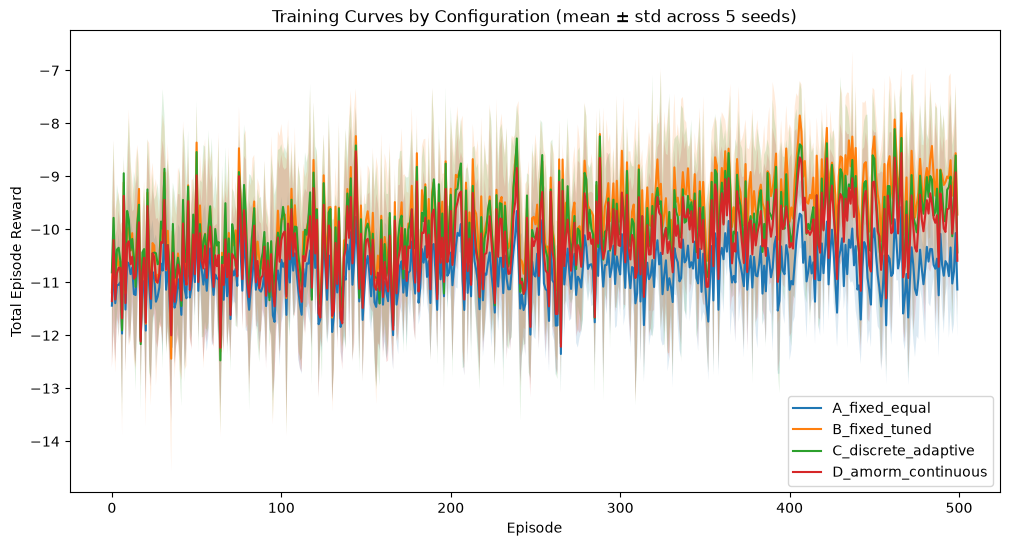

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

for config_name in CONFIGS:
    config_runs = [r["episode_rewards"] for r in all_results if r["config"] == config_name]
    config_runs = np.array(config_runs)          # shape: [num_seeds, num_episodes]
    mean_curve = config_runs.mean(axis=0)
    std_curve = config_runs.std(axis=0)

    episodes = np.arange(len(mean_curve))
    ax.plot(episodes, mean_curve, label=config_name)
    ax.fill_between(episodes, mean_curve - std_curve, mean_curve + std_curve, alpha=0.15)

ax.set_xlabel("Episode")
ax.set_ylabel("Total Episode Reward")
ax.set_title("Training Curves by Configuration (mean ± std across 5 seeds)")
ax.legend()
plt.show()

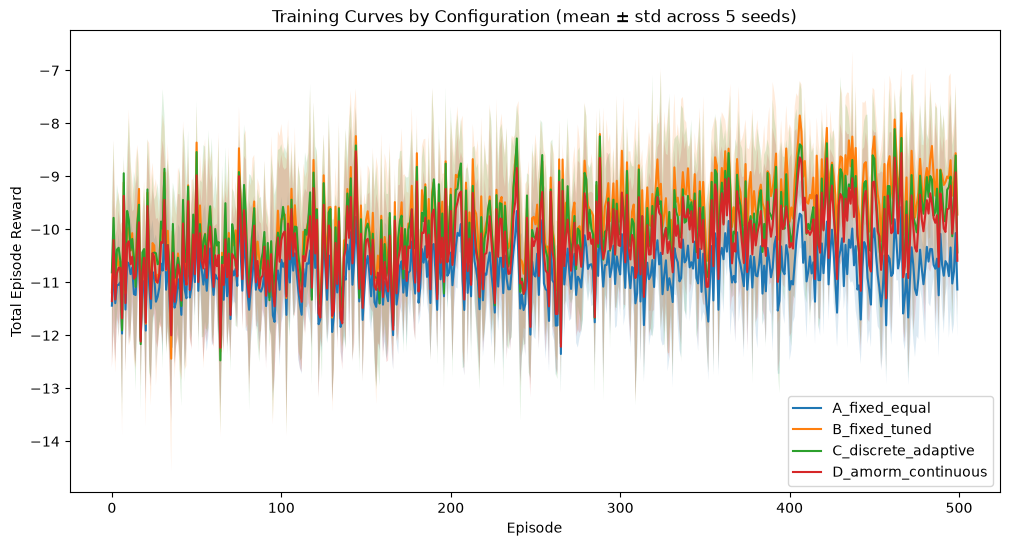

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

for config_name in CONFIGS:
    config_runs = [r["episode_rewards"] for r in all_results if r["config"] == config_name]
    config_runs = np.array(config_runs)          # shape: [num_seeds, num_episodes]
    mean_curve = config_runs.mean(axis=0)
    std_curve = config_runs.std(axis=0)

    episodes = np.arange(len(mean_curve))
    ax.plot(episodes, mean_curve, label=config_name)
    ax.fill_between(episodes, mean_curve - std_curve, mean_curve + std_curve, alpha=0.15)

ax.set_xlabel("Episode")
ax.set_ylabel("Total Episode Reward")
ax.set_title("Training Curves by Configuration (mean ± std across 5 seeds)")
ax.legend()
plt.show()

In [23]:
def random_baseline(weight_fn, num_episodes=20):
    env = MicrogridEnv(data=df, episode_length=24)
    totals = []
    for _ in range(num_episodes):
        obs, _ = env.reset()
        env.weights = np.array([1/3,1/3,1/3], dtype=np.float32)
        done = False
        ep_reward = 0
        while not done:
            actions = {a: env.action_space(a).sample() for a in env.possible_agents}
            env.weights = weight_fn(env, env.weights)
            obs, rewards, term, trunc, infos = env.step(actions)
            ep_reward += rewards[env.possible_agents[0]]
            done = term[env.possible_agents[0]] or trunc[env.possible_agents[0]]
        totals.append(ep_reward)
    return np.mean(totals)

print("Random baseline, Config A weights:", random_baseline(weights_config_A))

Random baseline, Config A weights: -7.599910417841708


Reward Signal Variance (RSV):

This gives you an early read on RQ2 ("does continuous adaptation reduce reward variance vs. discrete switching?"), though the full statistical treatment (TEC, TCE, GSI, HVI on a held-out test episode) belongs in Notebook 4 (Evaluation), not here.

In [24]:
#Reward Signal Variance

def compute_rsv(config_name, results):
    runs = [r["episode_rewards"] for r in results if r["config"] == config_name]
    runs = np.array(runs)
    per_episode_variance = runs.var(axis=0)   # variance across seeds, per episode
    return per_episode_variance.mean()        # averaged over training

rsv_C = compute_rsv("C_discrete_adaptive", all_results)
rsv_D = compute_rsv("D_amorm_continuous", all_results)

print(f"RSV (Config C - Discrete Adaptive): {rsv_C:.4f}")
print(f"RSV (Config D - AMORM Continuous):  {rsv_D:.4f}")
print(f"\nD lower than C: {rsv_D < rsv_C}")

RSV (Config C - Discrete Adaptive): 1.9200
RSV (Config D - AMORM Continuous):  1.5273

D lower than C: True
